# **EDA and Data Exploration**
## Group Members: Sai Prabhu (120820618)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import json
from scipy import stats
import seaborn as sns
from sklearn.decomposition import PCA

# **Understanding the Data**
  
## Loading and Exploring the Data

In [4]:
## Loading and Exploring the Data
col_datatypes = {
    "Report Number": str,
    "Local Case Number": str, 
    "Agency Name": str,
    "ACRS Report Type": str,
    "Crash Date/Time": str, 
    "Route Type": str, 
    "Road Name": str, 
    "Cross-Street Name": str, 
    "Off-Road Description": str, 
    "Municipality": str, 
    "Related Non-Motorist": str, 
    "Collision Type": str,
    "Weather": str,
    "Surface Condition": str,
    "Light": str,
    "Traffic Control": str,
    "Driver Substance Abuse": str,
    "Non-Motorist Substance Abuse": str,
    "Person ID": str,
    "Driver At Fault": str,
    "Injury Severity": str,
    "Circumstance": str,
    "Driver Distracted By": str,
    "Drivers License State": str,
    "Vehicle ID": str,
    "Vehicle Damage Extent": str,
    "Vehicle First Impact Location": str,
    "Vehicle Body Type": str,
    "Vehicle Movement": str,
    "Vehicle Going Dir": str,
    "Speed Limit": int,
    "Driverless Vehicle": str,
    "Parked Vehicle": str,
    "Vehicle Year": int,
    "Vehicle Make": str,
    "Vehicle Model": str,
    "Latitude": float,
    "Longitude": float,
    "Location": str
}

crash_df = pd.read_csv("Crash_Reporting_-_Drivers_Data.csv", dtype=col_datatypes)
print(f"Total Data Entries: {crash_df.shape[0]}")
print(f"Number of Features: {crash_df.shape[1]}")
print(f"Number of Numerical Features: {len(crash_df.select_dtypes(include=['int64', 'float64']).columns)}\n   \-> {list(crash_df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Number of Categorical Features: {len(crash_df.select_dtypes(include=['str']).columns)}\n   \-> {list(crash_df.select_dtypes(include=['str']).columns)}")
display(crash_df.head())

Total Data Entries: 210736
Number of Features: 39
Number of Numerical Features: 4
   \-> ['Speed Limit', 'Vehicle Year', 'Latitude', 'Longitude']
Number of Categorical Features: 35
   \-> ['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type', 'Crash Date/Time', 'Route Type', 'Road Name', 'Cross-Street Name', 'Off-Road Description', 'Municipality', 'Related Non-Motorist', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Substance Abuse', 'Non-Motorist Substance Abuse', 'Person ID', 'Driver At Fault', 'Injury Severity', 'Circumstance', 'Driver Distracted By', 'Drivers License State', 'Vehicle ID', 'Vehicle Damage Extent', 'Vehicle First Impact Location', 'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir', 'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Make', 'Vehicle Model', 'Location']


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,08/21/2025 05:21:00 PM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Northbound,40,No,No,2013,KIA,SOUL,39.219796,-77.257416,"(39.219796, -77.25741635)"
1,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,NaN,NaN,NaN,...,Northbound,55,No,No,0,NaN,NaN,39.180181,-77.250657,"(39.18018079, -77.25065714)"
2,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,07/25/2025 11:55:00 AM,Bicycle Route,NaN,NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,...,Westbound,40,No,No,2023,LEXUS,RX,39.121219,-76.988905,"(39.12121898, -76.98890509)"
3,MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,08/22/2025 10:36:00 AM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Southbound,30,No,No,2003,TOYOTA,SIENNA,39.207931,-77.141480,"(39.20793083, -77.1414795)"
4,MCP312900D6,250034573,MONTGOMERY,Property Damage Crash,08/03/2025 02:10:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT OF 2741 UNI...,NaN,...,Not On Roadway,0,No,No,2023,SUBARU,IMPREZA,39.039662,-77.057238,"(39.03966248, -77.05723843)"


## **Parsing and Adjusting the data**

## Converting Datatypes

In [5]:
### Lets convert the Crash Date/Time data from string to datetime format

crash_df["Crash Date/Time"] = crash_df["Crash Date/Time"].apply(lambda x: pd.to_datetime(x))

# Generate some new features based on the `Crash Date/Time` Column
crash_df["Season"]      = crash_df["Crash Date/Time"].apply(lambda x: "Winter" if (x.month == 12 or x.month <= 2) else ("Spring" if (x.month > 2 and x.month <= 5) else ("Summer" if (x.month > 5 and x.month <= 8) else "Fall")))
crash_df["Time of Day"] = crash_df["Crash Date/Time"].apply(lambda x: "Morning" if (x.hour < 12 and x.hour >= 5) else ("Afternoon" if (x.hour < 17 and x.hour >= 12) else ("Evening" if (x.hour < 21 and x.hour >= 17) else "Night")))
display(crash_df.head())

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,Season,Time of Day
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,2025-08-21 17:21:00,Maryland (State) Route,NaN,NaN,NaN,NaN,...,No,No,2013,KIA,SOUL,39.219796,-77.257416,"(39.219796, -77.25741635)",Summer,Evening
1,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,2025-08-22 10:44:00,Interstate (State),EISENHOWER MEMORIAL HWY,NaN,NaN,NaN,...,No,No,0,NaN,NaN,39.180181,-77.250657,"(39.18018079, -77.25065714)",Summer,Morning
2,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,2025-07-25 11:55:00,Bicycle Route,NaN,NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,...,No,No,2023,LEXUS,RX,39.121219,-76.988905,"(39.12121898, -76.98890509)",Summer,Morning
3,MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,2025-08-22 10:36:00,Maryland (State) Route,NaN,NaN,NaN,NaN,...,No,No,2003,TOYOTA,SIENNA,39.207931,-77.141480,"(39.20793083, -77.1414795)",Summer,Morning
4,MCP312900D6,250034573,MONTGOMERY,Property Damage Crash,2025-08-03 14:10:00,NaN,NaN,NaN,Parking Lot Way PARKING LOT OF 2741 UNI...,NaN,...,No,No,2023,SUBARU,IMPREZA,39.039662,-77.057238,"(39.03966248, -77.05723843)",Summer,Afternoon


### This block allows us to extrapolate further data points, such as season and time of day, for further analysis. In addition, we have changed the data type of `Crash Date/Time` column to be datetime type. 

_______________________________________________________________________________________________________________________________________________________

## Check how unique values vs total values:


In [6]:
total_entries = crash_df.shape[0]
unique_df = pd.DataFrame()
unique_df["Column Name"] = crash_df.columns
unique_df["Unique Values"] = unique_df["Column Name"].apply(lambda x: crash_df[x].nunique())
unique_df["Total Values"] = unique_df["Column Name"].apply(lambda x: total_entries - crash_df[x].isna().sum())
unique_df["Is Unique"] = unique_df["Unique Values"] == unique_df["Total Values"]
unique_df

,Column Name,Unique Values,Total Values,Is Unique
0,Report Number,118843,210736,False
1,Local Case Number,118729,210736,False
2,Agency Name,10,210736,False
3,ACRS Report Type,3,210736,False
4,Crash Date/Time,115943,210736,False
5,Route Type,19,190097,False
6,Road Name,4789,186385,False
7,Cross-Street Name,7536,170288,False
8,Off-Road Description,13978,19597,False
9,Municipality,20,19126,False


## Let's Graph it!

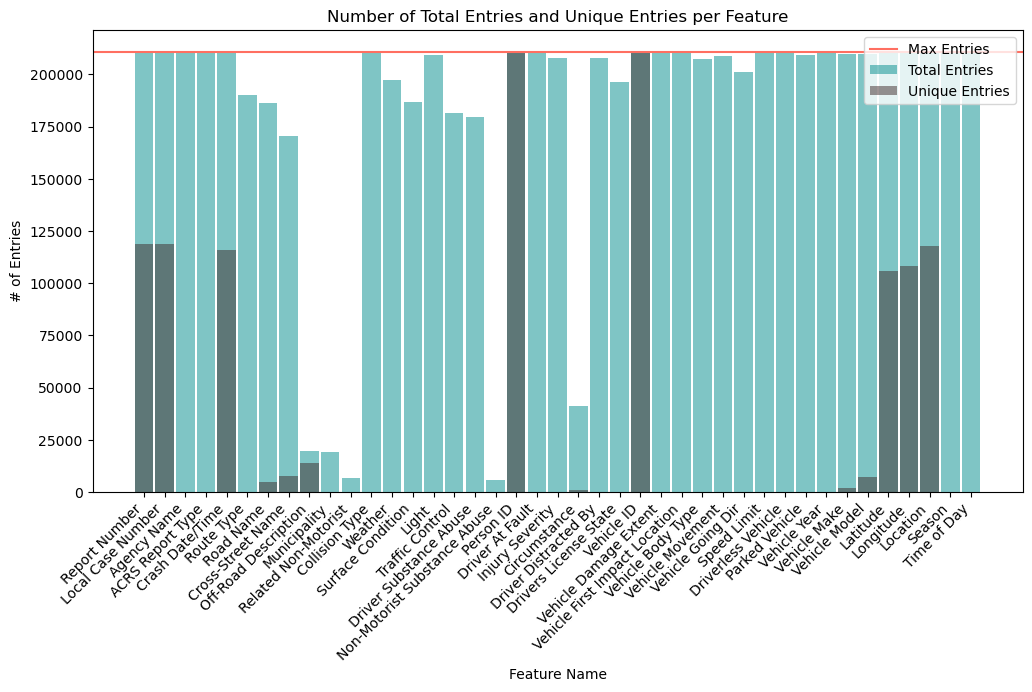

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(unique_df["Column Name"], unique_df["Total Values"], alpha=0.5, width=0.9, label="Total Entries", color="#008C8C")
plt.bar(unique_df["Column Name"], unique_df["Unique Values"], alpha=0.5, width=0.9, label="Unique Entries", color="#3E2A2A")
plt.axhline(total_entries, color='#FF6F61', label='Max Entries')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Feature Name")
plt.ylabel("# of Entries")
plt.title("Number of Total Entries and Unique Entries per Feature")
plt.legend(loc="upper right")
plt.show()

### This information lets us conclude that only the `Vehicle ID` and `Person ID` columns can be used as unique identifiers for our data. Looking at the graph we can also see the density of entries spread across the data. This leads us to think: How many missing values does each column have and how can we use this information to our advantage?

_______________________________________________________________________________________________________________________________________________________

## Understanding the missing values in our data

In [8]:
na_dict = {}
print("==============[ N/A Statistics ]==============")
print(f"Out of {crash_df.shape[0]} entries, the following number of entries have no values for the columns]\n")
print(f"Total Entries: {crash_df.shape[0]}")
na_dict = crash_df.isna().sum().astype(int).to_dict()
sorted_na = dict(sorted(na_dict.items(), key=lambda x: x[1], reverse=True))
print(json.dumps(sorted_na, indent=2))

==============[ N/A Statistics ]==============
Out of 210736 entries, the following number of entries have no values for the columns]

Total Entries: 210736
{
  "Non-Motorist Substance Abuse": 205003,
  "Related Non-Motorist": 203857,
  "Municipality": 191610,
  "Off-Road Description": 191139,
  "Circumstance": 169751,
  "Cross-Street Name": 40448,
  "Driver Substance Abuse": 31320,
  "Traffic Control": 29088,
  "Road Name": 24351,
  "Surface Condition": 23976,
  "Route Type": 20639,
  "Drivers License State": 14350,
  "Weather": 13356,
  "Vehicle Going Dir": 9525,
  "Vehicle Body Type": 3212,
  "Driver Distracted By": 2856,
  "Injury Severity": 2665,
  "Vehicle Movement": 1679,
  "Parked Vehicle": 1526,
  "Light": 1445,
  "Vehicle Model": 1174,
  "Vehicle Make": 1132,
  "Collision Type": 585,
  "Vehicle Damage Extent": 316,
  "Vehicle First Impact Location": 156,
  "Report Number": 0,
  "Local Case Number": 0,
  "Agency Name": 0,
  "ACRS Report Type": 0,
  "Crash Date/Time": 0,
  "Per

#### From the previous results, we can see that the columns `"Non-Motorist Substance Abuse"`, `"Related Non-Motorists"`, `"Municipality"`, `"Off-Road Description"`, `"Circumstance"`, `"Cross-Street Name"`, `"Driver Substance Abuse"`, and `"Traffic Control"` have over 25,000 missing values in the dataset. We can conclude that these columns should be reconsidered in our EDA as their omission would allow us to consider more datapoints. 

_______________________________________________________________________________________________________________________________________________________

# **Drawing Conclusions from Our Dataset**

# Distribution of the frequencies of time of day across crash data

### First lets plot the data to see how its distributed

,Morning,Afternoon,Evening,Night
0,62625,70302,49886,27923


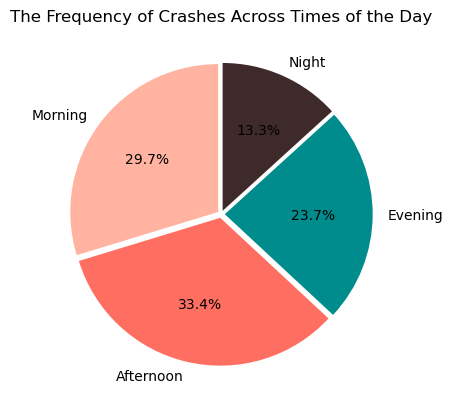

In [9]:
time_freq = pd.DataFrame(columns=["Morning", "Afternoon", "Evening", "Night"])
for time in crash_df["Time of Day"].unique():
    time_freq.loc[0, time] = crash_df[crash_df["Time of Day"] == time].shape[0]
    
display(time_freq)
plt.pie(time_freq.loc[0,:], explode=[0.025,0.025,0.025,0.025], labels=["Morning", "Afternoon", "Evening", "Night"], startangle=90, autopct="%1.1f%%", colors=["#FFB3A0", "#FF6F61", "#008C8C", "#3E2A2A"])
plt.title("The Frequency of Crashes Across Times of the Day")
plt.show()

After examining this graph, we have reason to believe there is a connection between crashes and times of the day. To test this hypothesis lets use the chi-squared test: 
   
Using the significance level of $\alpha = 0.05$
- HO: The frequency of crashes is equally distributed across `Time of Day`

- HA: The frequency of crashes is not equally distributed across `Time of Day`

In [10]:
chisquare_res = stats.chisquare((time_freq.loc[0,:].astype(float).values))

print(f"Chi-square Statistic: {chisquare_res.statistic}")
print(f"p-value: {chisquare_res.pvalue}")

Chi-square Statistic: 19553.438045706476
p-value: 0.0


## Conclusion
### Since this p-value is less than the significance level **(0.0 < 0.05)**, we can reject the Null Hypothesis(**HO**) and conclude that the frequency of crashes cannot be equally distributed across `Time of Day`

_______________________________________________________________________________________________________________________________________________________

# Outlier Testing for Vehicle Years

### Let's plot the data for vehicle years to see how its distributed

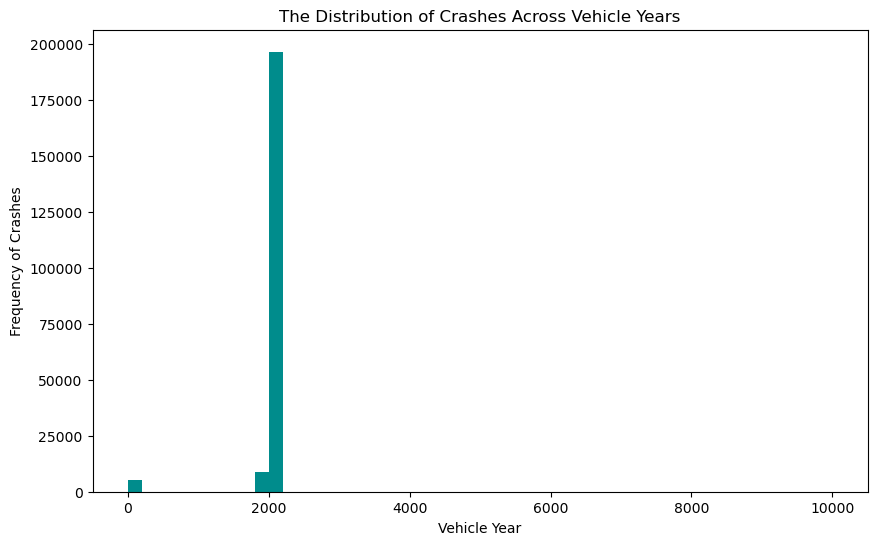

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(crash_df["Vehicle Year"], bins=50, color="#008C8C")
plt.xlabel("Vehicle Year")
plt.ylabel("Frequency of Crashes")
plt.title("The Distribution of Crashes Across Vehicle Years")
plt.show()

### Hmm... Something seems to be wrong with the distribution of values for `Vehicle Years`. The first problematic observation that can be made is the hump in the 0 bin. This, for obvious reasons, doesn't make sense for vehicle car years. In addition, we can see that the graph has auto-distributed across a range of `(0,10000)`. This tells us that there must be some low-frequency outliers towards the 10,000 mark that's spreading the graph thin.

## Let's explore this in further detail:

In [12]:
desc_stats = crash_df["Vehicle Year"].describe()
IQR = desc_stats["75%"] - desc_stats["25%"]
lower_bound = int(desc_stats["25%"] - (1.5*IQR))
upper_bound = int(desc_stats["75%"] + (1.5*IQR))
print(f"IQR:{IQR}")
print(f"We declare points outside of the range {lower_bound} <= x <= {upper_bound} an outlier")
print("This makes the following unique values outliers:")
vehicle_years = crash_df[(crash_df["Vehicle Year"]>upper_bound) | (crash_df["Vehicle Year"]<lower_bound)]["Vehicle Year"].unique()
print(vehicle_years)

IQR:10.0
We declare points outside of the range 1991 <= x <= 2031 an outlier
This makes the following unique values outliers:
[   0 1985 1968 1111 1900 1990 1988 1984 1987 1989 1986 1977 9999   99
 8888 1901 1981 2915 1983 2101 1966 2033  200 1982 1967 1971    3 1975
 1980 1978 1969  201 2918  215 2996 1965 2917 2103 2040 2107 2916   13
 1972 1960 1970   15 1911 2105    1 1938 1979 2991 1949 2997  202 1976
   97 3013 2914 5005 2911 2201 1140 1961 1005 1947 2099 1014 2100 1955
 2208 1974 2041 2200 7817 1930    8 1963 2048 2104 1015  198 2919 2102
 2055 3003 8008 2204 3863 2912    2  999 1008 1946   14 1959 1025 2998
 1234 1012    4 2205 1000 9000 3012 2109 2222 1957]


### Looking at the data, we can compute an `IQR` of 10 (2016 - 2006). This gives us a `lower_bound` and `upper_bound` of 1991 and 2031 respectively. When we calculate the possible outlier points, however, we allow implausible values to persist in our data. To ellaborate, an `upper_bound` of 2031 doesn't make sense to describe this feature, since the maximum possible value for `Vehicle Year` is 2027. For these reasons we might want to implement a manual cap for the upper bounds and keep the lower bounds the same.

### How about we implement a hardcap for the upperbounds?

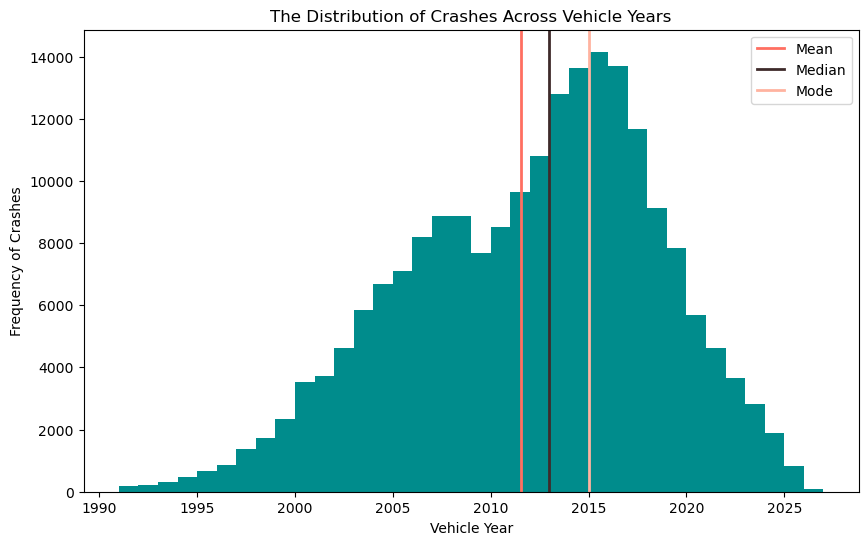

In [13]:
filtered_values = crash_df[(crash_df["Vehicle Year"]<=2027) & (crash_df["Vehicle Year"]>=lower_bound)]["Vehicle Year"]
#print(sorted(filtered_values.unique()))
plt.figure(figsize=(10, 6))
plt.hist(filtered_values, bins=36, range=(1991,2027), color="#008C8C")
plt.axvline(filtered_values.mean(), label="Mean", color="#FF6F61", lw=2.0)
plt.axvline(filtered_values.median(), label="Median", color="#3E2A2A", lw=2.0)
plt.axvline(filtered_values.mode()[0], label="Mode", color="#FFB3A0", lw=2.0)
plt.xlabel("Vehicle Year")
plt.ylabel("Frequency of Crashes")
plt.title("The Distribution of Crashes Across Vehicle Years")
plt.legend()
plt.show()

### With this showing promising results, lets drop any rows that fall outsides of the lower, upper range

In [14]:
out_of_bounds_idx = crash_df[(crash_df["Vehicle Year"]>2027) | (crash_df["Vehicle Year"]<lower_bound)].index
crash_df.drop(index=out_of_bounds_idx,axis=0,inplace=True)
print(f"Entries Left: {crash_df.shape[0]}, Entries Deleted: {total_entries-crash_df.shape[0]}")


Entries Left: 204692, Entries Deleted: 6044


## Conclusion  
### We can effectively select our lower and upper bounds for outliers by using a modified version of `IQR` outlier selection. We choose to use the lower bound from `IQR` because it provides an accurate representation of the data. For the upper bounds, however, we choose to select the maximum possible valid year for `Vehicle Years`. This allows us to pick the best possible range for outliers.
  
### In addition, we can conclude that the distribution of `Vehicle Years` is left-skewed since the **Mode > Median > Mean**. Furthermore, we can see that the data is bimodal with peaks at **2008** and **2016**

_______________________________________________________________________________________________________________________________________________________

## Correlation Testing Between Categorical Data

### In order to explore the relationships between our categorical features, we might opt to use a correlation heatmap. This type of graph can display the effective relationships between variables, which variables might be redundant, and allows us to pick the most useful features for future exploration.

### Lets start with creating our heatmap!

In [15]:
# ['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type', 'Crash Date/Time', 'Route Type', 'Road Name', 'Cross-Street Name', 'Off-Road Description', 'Municipality', 'Related Non-Motorist', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Substance Abuse', 'Non-Motorist Substance Abuse', 'Person ID', 'Driver At Fault', 'Injury Severity', 'Circumstance', 'Driver Distracted By', 'Drivers License State', 'Vehicle ID', 'Vehicle Damage Extent', 'Vehicle First Impact Location', 'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir', 'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Make', 'Vehicle Model', 'Location']
# `"Non-Motorist Substance Abuse"`, `"Related Non-Motorists"`, `"Municipality"`, `"Off-Road Description"`, `"Circumstance"`, `"Cross-Street Name"`, `"Driver Substance Abuse"`, and `"Traffic Control"`
# ['Agency Name', 'ACRS Report Type', 'Time of Day', 'Route Type', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Driver At Fault', 'Injury Severity', 'Driver Distracted By', 'Vehicle Damage Extent', 'Vehicle Body Type', 'Parked Vehicle', 'Vehicle Make', 'Vehicle Model']
cat_cols = ["Agency Name", "ACRS Report Type", "Time of Day", "Route Type", "Collision Type", "Weather", "Surface Condition", "Light", "Driver At Fault", "Injury Severity", "Driver Distracted By", "Vehicle Damage Extent", "Vehicle Body Type", "Parked Vehicle"]
cat_df = crash_df[cat_cols].dropna()
heat_map = pd.DataFrame(index=cat_cols, columns=cat_cols)

for x in cat_cols:
    for y in cat_cols:
        contingency_table = stats.contingency.crosstab(cat_df[x].astype(str), cat_df[y].astype(str))
        #display(contingency_table.count)
        heat_map.loc[x,y] = stats.contingency.association(contingency_table.count, method='cramer')
#display(heat_map)

## Let's plot it!

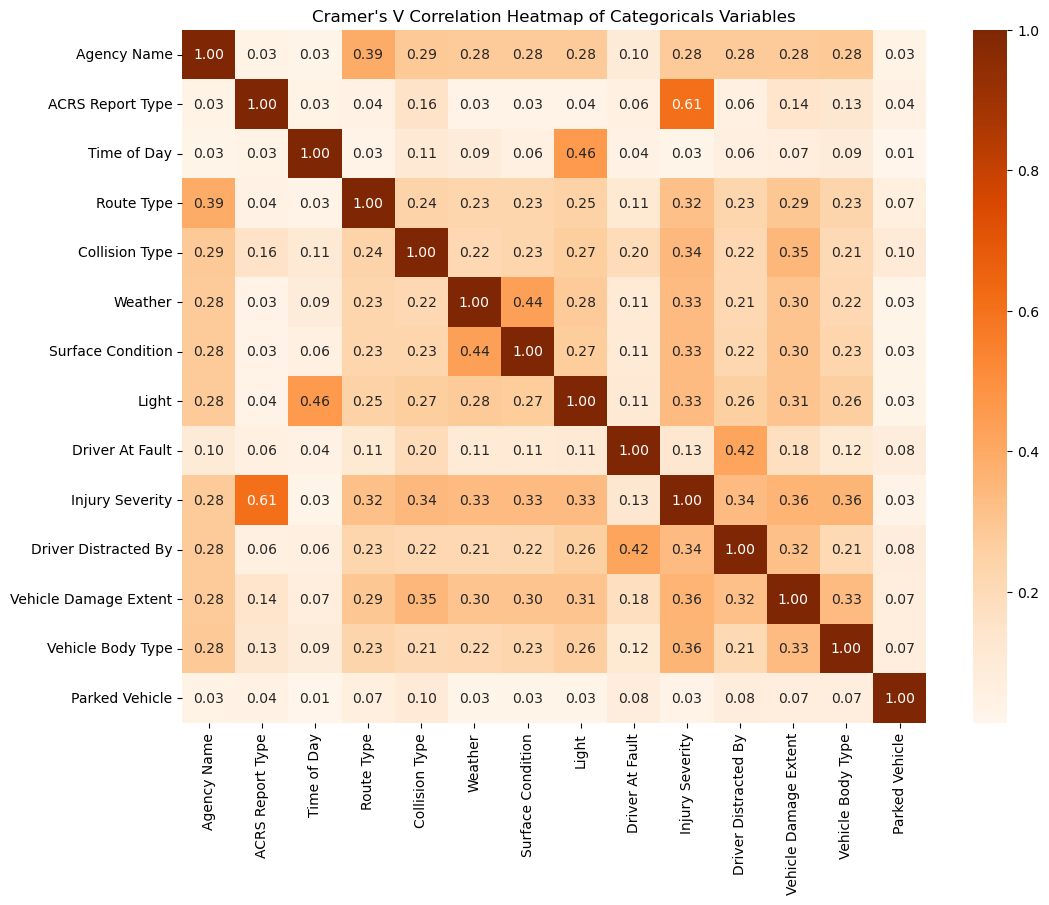

In [16]:
plt.figure(figsize=(12, 9))
sns.heatmap(heat_map.astype(float), annot=True, cmap='Oranges', fmt='.2f')
plt.title("Cramer's V Correlation Heatmap of Categoricals Variables")
plt
plt.show()

In [17]:
rankings_dict = {}
for row_idx in range(len(heat_map.columns)):
    for col_idx in range(len(heat_map.columns)):
        if col_idx >= row_idx:
            continue
        rankings_dict[(heat_map.columns[row_idx], heat_map.columns[col_idx])] = heat_map.iloc[row_idx, col_idx]
sorted_dict = dict(sorted(rankings_dict.items(), key=lambda x: x[1], reverse=True))

for key in sorted_dict:
    if sorted_dict[key] >= 0.35:
        print(f" Columns {key[0]} and {key[1]} have a Cramer's coefficient of {sorted_dict[key]}")

 Columns Injury Severity and ACRS Report Type have a Cramer's coefficient of 0.6104168426511564
 Columns Light and Time of Day have a Cramer's coefficient of 0.4599648015456318
 Columns Surface Condition and Weather have a Cramer's coefficient of 0.43691921665480865
 Columns Driver Distracted By and Driver At Fault have a Cramer's coefficient of 0.41909377599678316
 Columns Route Type and Agency Name have a Cramer's coefficient of 0.3941477702609246
 Columns Vehicle Damage Extent and Injury Severity have a Cramer's coefficient of 0.36273025600925063
 Columns Vehicle Body Type and Injury Severity have a Cramer's coefficient of 0.35855227718280197
 Columns Vehicle Damage Extent and Collision Type have a Cramer's coefficient of 0.3508490199403347


## Conclusion  
### From this heat map and ranking of information we can conclude which categorical features would be correlated. From our findings, we can conclude from the `(Injury Severity, ACRS Report Type)`, `(Driver Distracted, Injury Severity)`, `(Driver Distracted, Driver At Fault)`, `(Damage Extent, Injury Severity)`, `(Surface Condition, Weather)`, `(Route Type, Agency Name)`, `(Vehicle Damage Extent, Driver Distracted)` are strongly linked as they have a Cramer's V > 0.35. 
###  **It's important to note** that we cannot conlude that these variables are positively or negatively correlated, only that knowing one can be a meaningful way of predicting the other. 
  

_______________________________________________________________________________________________________________________________________________________

### map the values in agency to make it relevant and use frequency encoder to make it numerical

In [18]:
agency_mapping = {
    "MONTGOMERY": "Montgomery County Police",
    "TAKOMA": "Takoma Park Police Depart",
    "GAITHERSBURG": "Gaithersburg Police Depar",
    "ROCKVILLE": "Rockville Police Departme",
    "MCPARK": "Maryland-National Capital"
}
crash_df["Agency Name"] = crash_df["Agency Name"].replace(agency_mapping)

### Might get faded
freq_count = crash_df["Agency Name"].value_counts()
crash_df["Agency Name Freq Count"] = crash_df["Agency Name"].map(freq_count)

### Combine all make and model into a new feature and see the distribution of the combined feature, fade bottom 5% of values.

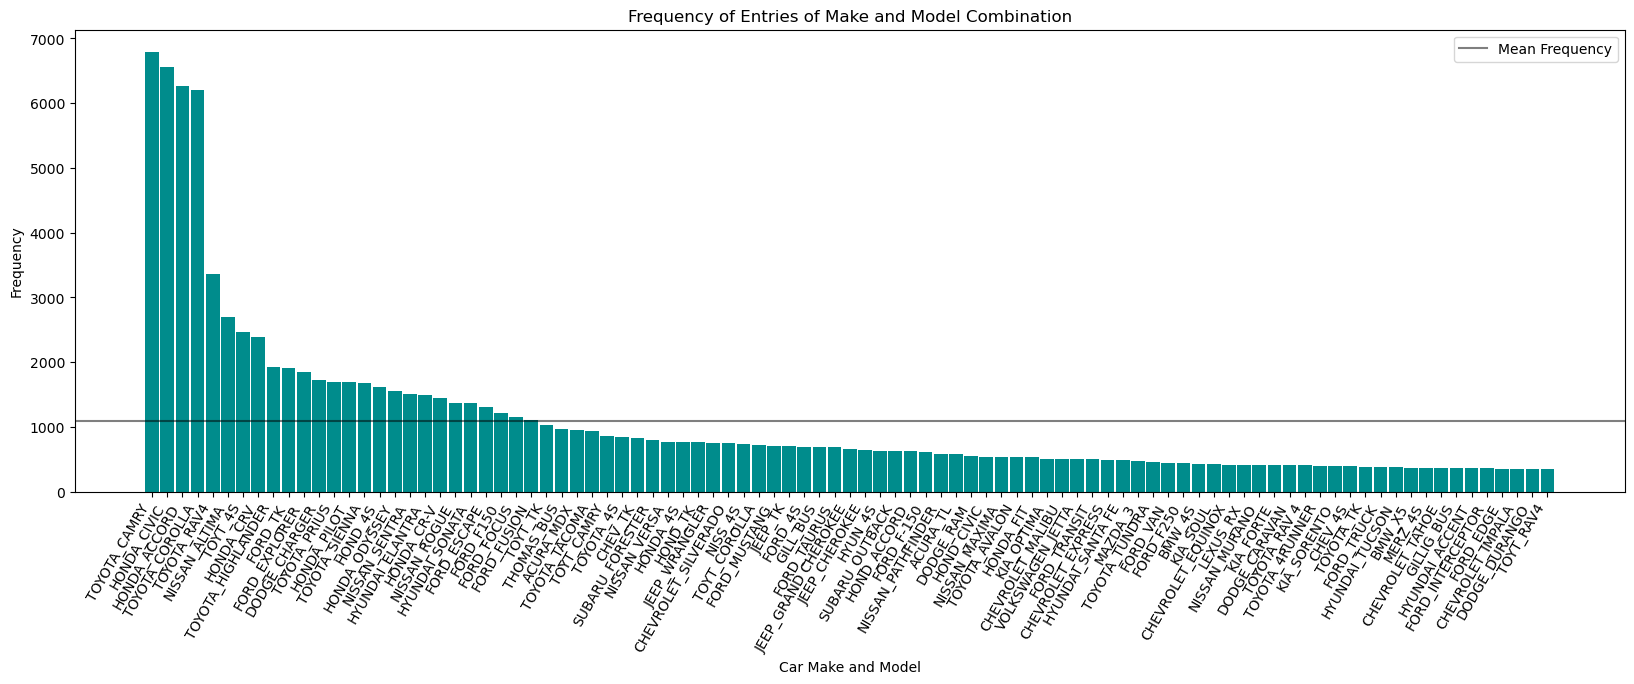

In [19]:
crash_df["MakeModel"] = crash_df["Vehicle Make"] + "_" + crash_df["Vehicle Model"]

makemode_freq = crash_df["MakeModel"].value_counts()
filtered_makemodels = makemode_freq[makemode_freq.values > (0.05*makemode_freq.values[0])]
plt.figure(figsize=(20,6))
plt.bar(filtered_makemodels.index, filtered_makemodels.values, width=.9, color="#008C8C")
plt.xticks(rotation=60, ha='right')
plt.xlabel("Car Make and Model")
plt.ylabel("Frequency")
plt.title("Frequency of Entries of Make and Model Combination")
plt.axhline((filtered_makemodels.values.mean()), label="Mean Frequency", color='black', alpha = 0.5)
plt.legend()
plt.show()

### Apply frequency filtering for feature column

In [20]:
valid_makemodel = list(makemode_freq[makemode_freq.values > (0.05*makemode_freq.values[0])].index)
crash_df = crash_df[crash_df["MakeModel"].isin(valid_makemodel)]


### examine the number of unique categories for each categorical data

In [21]:
print(crash_df[cat_cols].nunique())
print()
print(crash_df[["MakeModel"]].nunique())

Agency Name               5
ACRS Report Type          3
Time of Day               4
Route Type               19
Collision Type           28
Weather                  23
Surface Condition        20
Light                    16
Driver At Fault           3
Injury Severity          10
Driver Distracted By     24
Vehicle Damage Extent    12
Vehicle Body Type        49
Parked Vehicle            2
dtype: int64

MakeModel    93
dtype: int64


In [22]:
target_col = ["MakeModel"]
feature_col = cat_cols+["Speed Limit", "Vehicle Year"]
X = crash_df[feature_col]
y = crash_df[target_col]
print(f"X dims:        {X.shape}\ny dims:        {y.shape}\ncombined dims: ({X.shape[0] + y.shape[0]}, {X.shape[1] + y.shape[1]})")

X dims:        (101865, 16)
y dims:        (101865, 1)
combined dims: (203730, 17)


In [23]:
crash_df.columns

Index(['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type',
       'Crash Date/Time', 'Route Type', 'Road Name', 'Cross-Street Name',
       'Off-Road Description', 'Municipality', 'Related Non-Motorist',
       'Collision Type', 'Weather', 'Surface Condition', 'Light',
       'Traffic Control', 'Driver Substance Abuse',
       'Non-Motorist Substance Abuse', 'Person ID', 'Driver At Fault',
       'Injury Severity', 'Circumstance', 'Driver Distracted By',
       'Drivers License State', 'Vehicle ID', 'Vehicle Damage Extent',
       'Vehicle First Impact Location', 'Vehicle Body Type',
       'Vehicle Movement', 'Vehicle Going Dir', 'Speed Limit',
       'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Year', 'Vehicle Make',
       'Vehicle Model', 'Latitude', 'Longitude', 'Location', 'Season',
       'Time of Day', 'Agency Name Freq Count', 'MakeModel'],
      dtype='str')

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)